# Analysing data with non-gaussian resolution functions

`refnx` can analyse data with non-gaussian resolution kernels. This typically occurs on instruments whose angular and wavelength resolutions are mismatched in width and one or both non-gaussian in nature. For example on a chopper time-of-flight reflectometer the wavelength resolution is typically rectangular in shape, and can be much broader than the trapezoidal angular resolution. When the two are convolved the overall Q-resolution ends up being trapezoidal as well.

This situation often occurs on Platypus and Spatz, and will also be the case on the European Spallation Source reflectometers. For further details please see:

    A. Nelson and C. Dewhurst, Towards a detailed resolution smearing kernel for time-of-flight neutron reflectometers, J. Appl. Cryst. (2013) 46, 1338-1343

The [refnx-models](https://github.com/refnx/refnx-models/) respository contains [code](https://github.com/refnx/refnx-models/blob/main/platypus-simulate/reflect_simulator.py) for the Monte Carlo simulation of reflectivity curves. One [notebook](https://github.com/refnx/refnx-models/blob/main/platypus-simulate/Platypus_simulator.ipynb) demonstrates how non-gaussian resolution kernels occur. Here we'll analyse a dataset simulated in a non-gaussian resolution context.

The file in which it's saved is a non-standard format, which requires a specific way to load it. 

In [1]:
# first of all let's get the dataset
import urllib.request  # for retrieving URL
import shutil

url = "https://github.com/refnx/refnx-models/raw/refs/heads/main/platypus-simulate/detailed_kernel.h5"

# download the refnx-test data repo as a zip, and write the zip file
# to the current directory.
with (
    urllib.request.urlopen(url, timeout=5) as response,
    open("detailed_kernel.h5", "wb") as f,
):
    shutil.copyfileobj(response, f)

The non-standard way of loading this file into `refnx` follows.

In [4]:
from refnx.dataset.data1d import _hdf_to_data1d
data = _hdf_to_data1d("detailed_kernel.h5")

The detailed resolution function is specified in the `x_err` attribute. Here are some properties of this dataset:

In [10]:
print(f"{len(data)=}")
print(f"{data.x_err.shape=}")

len(data)=171
data.x_err.shape=(171, 2, 51)


This resolution kernel contained in `data.x_err` is a probability distribution function (PDF). `x_err` has the shape `(qvals.shape, 2, M)`. Here `qvals` is the number of points in the dataset, with there being `M` points in the kernel. `data.x_err[:, 0, :]` holds the q values for the kernel, `data.x_err[:, 1, :]` gives the corresponding probability.

If you have a detailed resolution kernel that you wish to use the important feature is to get the shape of the `x_err` array correct. Here I'll demonstrate how to insert the `x_arr` array.

In [76]:
import numpy as np
from refnx.dataset import Data1D
rng = np.random.default_rng(12909)

# q, r, dr all have the same shape.
# Here I'm using random numbers for the data. You obviously use real data.
dummy_qvals = np.geomspace(0.01, 0.2, 171)
dummy_rvals = rng.uniform(size=171)
dummy_evals = rng.uniform(size=171)

dummy_data = Data1D((dummy_qvals, dummy_rvals, dummy_evals))
# 171 data points, with the PDF shape for each of those data points being (2, 51).
# i.e.
# x_err[2, 0, :] describes the q basis for the third datapoint (indexing starts from zero)
# x_err[2, 1, :] describes the corresponding probability 
dummy_data.x_err = rng.uniform(size=(171, 2, 51))

Returning to the simulated dataset, let's have a look at the PDF for one of the datapoints. The resolution kernel is clearly trapezoidal in nature.

In [11]:
import matplotlib.pyplot as plt

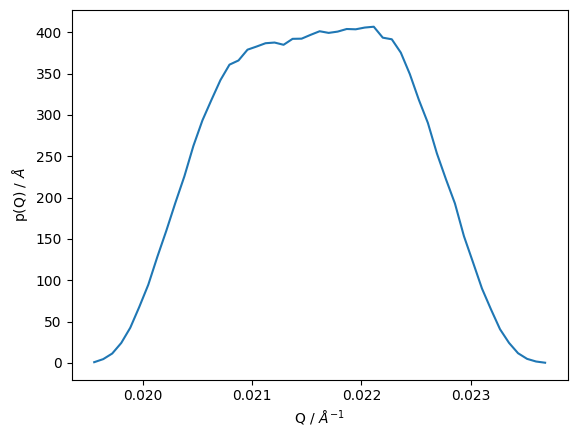

In [69]:
# let's look at the 50th point.
plt.plot(data.x_err[50, 0], data.x_err[50, 1]);
plt.ylabel("p(Q) / $\\AA$")
plt.xlabel("Q / $\\AA^{-1}$");

Now we'll go on to analyse this data in `refnx`, using the detailed kernel. We know the original parameters used to create the data, so we'll go straight to using those.

In [21]:
from refnx.analysis import Objective, CurveFitter
from refnx.reflect import SLD, ReflectModel

In [24]:
air = SLD(0)
sio2 = SLD(3.47)
si = SLD(2.07)

s = air | sio2(225, 3) | si(0, 3)
model = ReflectModel(s, bkg=5e-7)
objective = Objective(model, data)

By default the `ReflectModel` automatically uses the detailed resolution function in the analysis, as long as it's contained in `x_err` and `x_err` has the correct shape. Let's look at the residuals using the detailed resolution kernel, and compare that to the residuals calculated using a gaussian approximation.

Detailed kernel: objective.chisqr()/len(data) = np.float64(1.2638710247128122)
Gaussian-equivalent kernel: objective.chisqr()/len(data) = np.float64(1.6251102135033868)


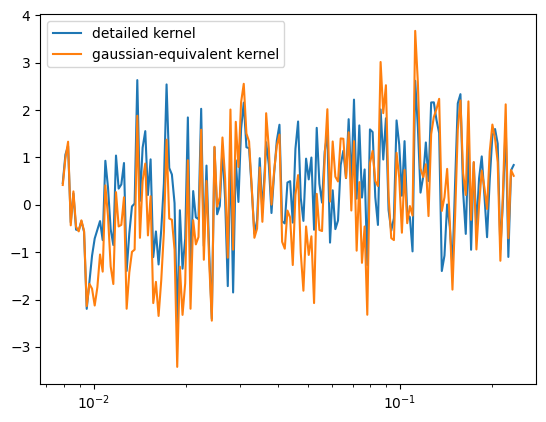

In [47]:
plt.plot(data.x, objective.residuals(), label="detailed kernel")
print(f"Detailed kernel: {objective.chisqr()/len(data) = }")

# now for the residuals calculated by the gaussian-equivalent dataset.
model.dq = 8.49
model.dq_type = "constant"
plt.plot(data.x, objective.residuals(), label="gaussian-equivalent kernel")
print(f"Gaussian-equivalent kernel: {objective.chisqr()/len(data) = }")

# return to detailed kernel
model.dq_type = "pointwise"

plt.xscale("log");
plt.legend();

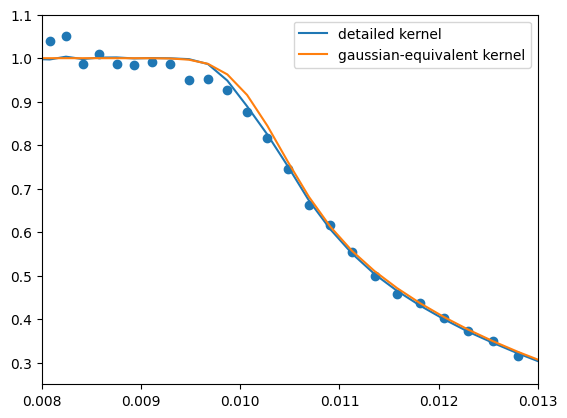

In [66]:
plt.scatter(data.x, data.y)
plt.plot(data.x, objective.generative(), label="detailed kernel")

model.dq = 8.49
model.dq_type = "constant"
plt.plot(data.x, objective.generative(), label="gaussian-equivalent kernel")

# return to detailed kernel
model.dq_type = "pointwise"

# plt.xscale("log");
# plt.yscale("log");
plt.legend();
plt.xlim(0.008, 0.013);
plt.ylim(0.25, 1.1);

The detailed kernel does describe the data around the critical edge better, although not to an earth shattering extent. The paper given above shows various scenarios where the detailed resolution kernel becomes vital.